# Clustering Model Exploration

This notebook reuses the preprocessing already done in `preprocessing.ipynb` and builds a clustering based credit risk model.

The idea is:
- cluster borrowers based on their financial and credit profile,
- measure the default rate inside each cluster,
- turn cluster membership into a probability of default for a new applicant.


## Why GMM is the best fit here

Clustering is unsupervised, so it does not directly predict `loan_status`. Instead, it groups similar borrowers together.

Gaussian Mixture Models (GMMs) are a strong choice here because they give soft cluster memberships. That means a borrower can partially belong to multiple clusters, which makes it natural to estimate a probability of default rather than a hard yes/no label.

For a borrower `x`, we estimate:

`P(default | x) = sum_k P(cluster_k | x) * default_rate(cluster_k)`

We will use silhouette score to judge clustering quality, to measure how well separated our clusters are. We will also report ROC-AUC and Brier score so we can see whether the resulting probabilities are actually useful for default prediction.


In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, roc_auc_score, brier_score_loss


In [98]:
# Load the dataset
df = pd.read_csv("data/credit_risk_dataset.csv")
df = df.drop_duplicates().copy()

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (32416, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [99]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (25932, 11)
Test shape: (6484, 11)


In [100]:
# Reusing the same data cleaning logic from preprocessing.ipynb
def clean_invalid_rows(df):
    df = df.copy()
    df = df[(df["person_age"] > 0) & (df["person_age"] < 100)]
    df = df[df["person_income"] > 0]
    df = df[df["loan_amnt"] > 0]
    df = df[
        (df["person_emp_length"].isna())
        | ((df["person_emp_length"] >= 0) & (df["person_emp_length"] <= 50))
    ]
    df = df[
        (df["person_emp_length"].isna())
        | (df["person_emp_length"] <= df["person_age"])
    ]
    df = df[(df["loan_int_rate"].isna()) | (df["loan_int_rate"] > 0)]
    return df


X_train = clean_invalid_rows(X_train)
y_train = y_train.loc[X_train.index]

X_test = clean_invalid_rows(X_test)
y_test = y_test.loc[X_test.index]

print("Cleaned train shape:", X_train.shape)
print("Cleaned test shape:", X_test.shape)

Cleaned train shape: (25925, 11)
Cleaned test shape: (6484, 11)


In [101]:
# Reusing the same engineered features from preprocessing.ipynb
def add_engineered_features(df):
    df = df.copy()
    df["income_to_loan_ratio"] = df["person_income"] / df["loan_amnt"]
    df["emp_length_to_age_ratio"] = df["person_emp_length"] / df["person_age"]
    return df


X_train = add_engineered_features(X_train)
X_test = add_engineered_features(X_test)

display(X_train.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_to_loan_ratio,emp_length_to_age_ratio
7173,23,75800,RENT,0.0,PERSONAL,A,7000,6.54,0.09,N,2,10.828571,0.000000
16396,25,61959,RENT,9.0,EDUCATION,C,25000,12.73,0.40,Y,4,2.478360,0.360000
21744,31,53088,RENT,0.0,PERSONAL,A,6000,6.54,0.11,N,9,8.848000,0.000000
27805,27,228000,MORTGAGE,12.0,HOMEIMPROVEMENT,A,6000,7.14,0.03,N,6,38.000000,0.444444
24563,29,54000,RENT,0.0,PERSONAL,D,10000,14.96,0.19,N,9,5.400000,0.000000


In [102]:
# Reusing the same preprocessing pipeline from preprocessing.ipynb
categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

log_features = ["person_income", "loan_amnt", "income_to_loan_ratio"]

numeric_features = [
    "person_age",
    "person_emp_length",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "emp_length_to_age_ratio"
]

log_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("log_num", log_transformer, log_features),
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("Number of engineered/preprocessed features:", len(feature_names))

Processed train shape: (25925, 28)
Processed test shape: (6484, 28)
Number of engineered/preprocessed features: 28


In [103]:
# GMM and silhouette score work best with dense arrays
def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)


X_train_dense = to_dense(X_train_processed)
X_test_dense = to_dense(X_test_processed)
silhouette_sample_size = min(5000, len(X_train_dense))

print("Dense train shape:", X_train_dense.shape)
print("Dense test shape:", X_test_dense.shape)
print("Silhouette sample size:", silhouette_sample_size)

Dense train shape: (25925, 28)
Dense test shape: (6484, 28)
Silhouette sample size: 5000


## Choose the number of clusters with silhouette score

We compare several values of `n_components` for the GMM. Using silhouette we can judge how well separated the resulting clusters are.


In [104]:
component_range = range(2, 9)
model_selection_results = []

for n_components in component_range:
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="diag",
        n_init=5,
        random_state=42
    )
    gmm.fit(X_train_dense)
    train_clusters = gmm.predict(X_train_dense)

    silhouette = silhouette_score(
        X_train_dense,
        train_clusters,
        sample_size=silhouette_sample_size,
        random_state=42
    )

    model_selection_results.append({
        "n_components": n_components,
        "silhouette_score": silhouette
    })

results_df = pd.DataFrame(model_selection_results)
display(results_df.sort_values("silhouette_score", ascending=False))

,n_components,silhouette_score
0,2,0.101974
1,3,0.087924
2,4,0.075406
3,5,0.057158
6,8,0.054570
5,7,0.037896
4,6,0.027566


In [105]:
best_n = int(results_df.loc[results_df["silhouette_score"].idxmax(), "n_components"])
print("Best number of components by silhouette score:", best_n)

Best number of components by silhouette score: 2


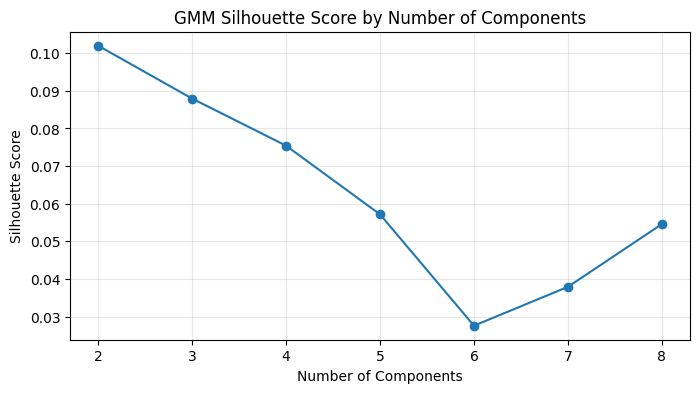

In [106]:
plt.figure(figsize=(8, 4))
plt.plot(results_df["n_components"], results_df["silhouette_score"], marker="o")
plt.title("GMM Silhouette Score by Number of Components")
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.xticks(list(component_range))
plt.grid(True, alpha=0.3)
plt.show()

## Fit the final GMM model

We now fit the final GMM using the number of components with the best silhouette score.


In [107]:
final_gmm = GaussianMixture(
    n_components=best_n,
    covariance_type="diag",
    n_init=10,
    random_state=42
)

final_gmm.fit(X_train_dense)

train_clusters = final_gmm.predict(X_train_dense)
test_clusters = final_gmm.predict(X_test_dense)

final_silhouette = silhouette_score(
    X_train_dense,
    train_clusters,
    sample_size=silhouette_sample_size,
    random_state=42
)
print("Final silhouette score:", round(final_silhouette, 4))

Final silhouette score: 0.102


In [108]:
# Measure default rate inside each training cluster
cluster_summary = pd.DataFrame({
    "cluster": train_clusters,
    "loan_status": y_train.to_numpy()
})

cluster_stats = (
    cluster_summary.groupby("cluster")
    .agg(cluster_size=("loan_status", "size"), default_rate=("loan_status", "mean"))
    .sort_values("default_rate", ascending=False)
)

display(cluster_stats)

,cluster_size,default_rate
cluster,,
1,1080,0.642593
0,24845,0.200282


## Visualize the clusters

Because the processed feature space has many dimensions, we use PCA to project the training data into 2 dimensions for visualization only. Each point is a borrower, colored by its assigned GMM cluster.


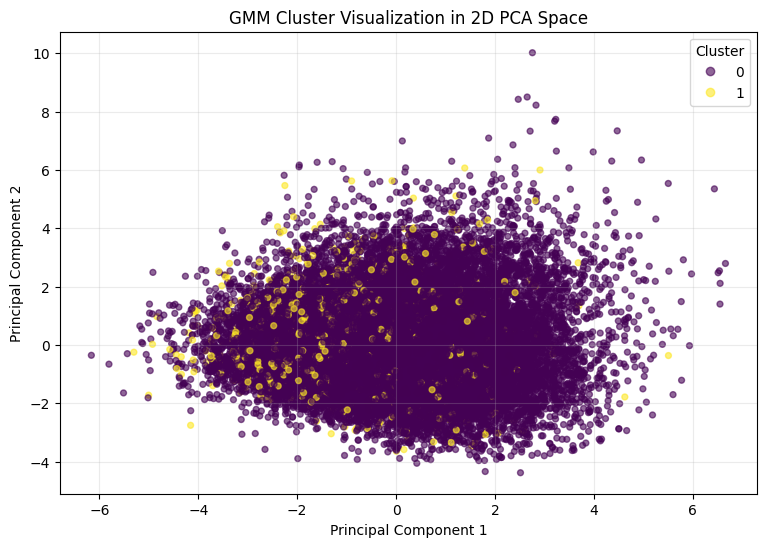

In [109]:
pca = PCA(n_components=2, random_state=42)
train_pca = pca.fit_transform(X_train_dense)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    train_pca[:, 0],
    train_pca[:, 1],
    c=train_clusters,
    cmap="viridis",
    alpha=0.6,
    s=18
)
plt.title("GMM Cluster Visualization in 2D PCA Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
legend_handles, legend_labels = scatter.legend_elements()
plt.legend(legend_handles, legend_labels, title="Cluster", loc="best")
plt.grid(True, alpha=0.25)
plt.show()

In [110]:
# Convert soft cluster memberships into probability of default
train_membership_probs = final_gmm.predict_proba(X_train_dense)
test_membership_probs = final_gmm.predict_proba(X_test_dense)

cluster_default_rates = cluster_stats.sort_index()["default_rate"].to_numpy()

train_default_probability = train_membership_probs @ cluster_default_rates
test_default_probability = test_membership_probs @ cluster_default_rates

print("First 10 predicted default probabilities:")
print(np.round(test_default_probability[:10], 4))

First 10 predicted default probabilities:
[0.6426 0.2003 0.2003 0.2003 0.2003 0.2003 0.6426 0.2003 0.2003 0.2003]


In [111]:
# Evaluate the probability estimates
roc_auc = roc_auc_score(y_test, test_default_probability)
brier = brier_score_loss(y_test, test_default_probability)

evaluation_summary = pd.DataFrame({
    "metric": ["silhouette_score", "roc_auc", "brier_score"],
    "value": [final_silhouette, roc_auc, brier]
})

display(evaluation_summary)

,metric,value
0,silhouette_score,0.101974
1,roc_auc,0.556673
2,brier_score,0.162294


In [112]:
# Look at a few example predictions
prediction_examples = X_test.copy().reset_index(drop=True)
prediction_examples["actual_default"] = y_test.reset_index(drop=True)
prediction_examples["predicted_default_probability"] = test_default_probability
prediction_examples["assigned_cluster"] = test_clusters

display(
    prediction_examples[
        [
            "person_income",
            "loan_amnt",
            "loan_int_rate",
            "loan_percent_income",
            "loan_grade",
            "actual_default",
            "predicted_default_probability",
            "assigned_cluster"
        ]
    ].head(15)
)

,person_income,loan_amnt,loan_int_rate,loan_percent_income,loan_grade,actual_default,predicted_default_probability,assigned_cluster
0,56461,5400,15.68,0.10,E,0,0.642593,1
1,108000,4925,NaN,0.05,B,1,0.200282,0
2,102000,18000,9.33,0.18,B,0,0.200282,0
3,45000,10000,12.42,0.22,B,0,0.200282,0
4,30000,12000,10.39,0.40,B,1,0.200282,0
5,113000,9600,NaN,0.08,C,0,0.200282,0
6,73000,16000,19.41,0.22,F,1,0.642593,1
7,90000,7500,15.58,0.08,D,0,0.200282,0
8,135000,24250,12.87,0.18,C,0,0.200282,0
9,52000,8000,7.51,0.15,A,0,0.200282,0


## Extra evaluation plots

These plots help us compare the assigned clusters and predicted probabilities against the actual default outcomes.

How to read them:
- In the `Actual Default Rate by Assigned Cluster` plot, each bar shows the fraction of borrowers in that cluster who actually defaulted. If one cluster has a much higher bar than another, then the clustering has captured some difference in risk level.
- In the `Predicted Default Probability by Actual Outcome` plot, we compare the predicted probabilities for borrowers who actually defaulted (`1`) and those who did not (`0`). Ideally, these two groups should be clearly separated, with defaulters shifted toward higher probabilities. If they overlap a lot, then the model is not distinguishing the two groups very well.


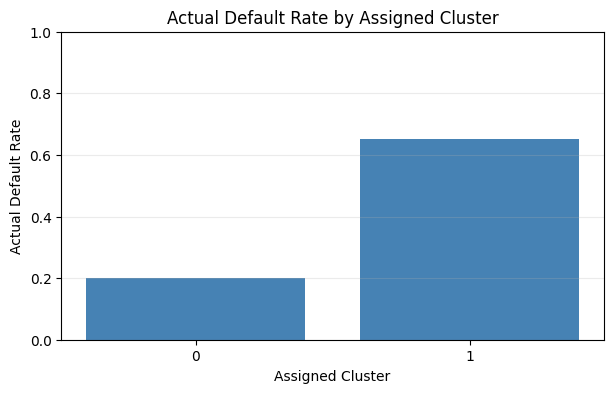

In [113]:
cluster_eval_df = pd.DataFrame({
    "assigned_cluster": test_clusters,
    "actual_default": y_test.to_numpy(),
    "predicted_default_probability": test_default_probability
})

cluster_default_comparison = (
    cluster_eval_df.groupby("assigned_cluster")["actual_default"]
    .mean()
    .reset_index(name="actual_default_rate")
)

plt.figure(figsize=(7, 4))
plt.bar(
    cluster_default_comparison["assigned_cluster"].astype(str),
    cluster_default_comparison["actual_default_rate"],
    color="steelblue"
)
plt.title("Actual Default Rate by Assigned Cluster")
plt.xlabel("Assigned Cluster")
plt.ylabel("Actual Default Rate")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.25)
plt.show()

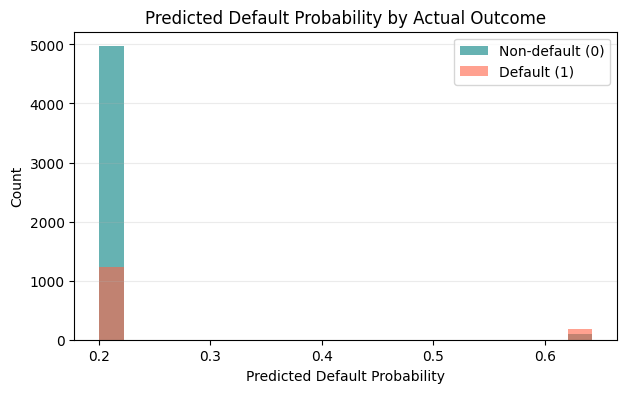

In [114]:
plt.figure(figsize=(7, 4))
plt.hist(
    cluster_eval_df.loc[cluster_eval_df["actual_default"] == 0, "predicted_default_probability"],
    bins=20,
    alpha=0.6,
    label="Non-default (0)",
    color="teal"
)
plt.hist(
    cluster_eval_df.loc[cluster_eval_df["actual_default"] == 1, "predicted_default_probability"],
    bins=20,
    alpha=0.6,
    label="Default (1)",
    color="tomato"
)
plt.title("Predicted Default Probability by Actual Outcome")
plt.xlabel("Predicted Default Probability")
plt.ylabel("Count")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()

## What We Learned

This modeling approach taught us several useful things about using clustering for credit-risk prediction.

First, the silhouette scores are low and close to zero, which suggests that the clusters are not strongly separated. This means many points sit near the boundary between clusters, so there is considerable overlap. We can also see this in the visualization, where the colored groups blend together rather than forming clearly distinct regions.

It also makes sense that the highest silhouette score happened when `n_components = 2`. At a high level, credit risk naturally suggests two broad groups: borrowers who are lower risk and borrowers who are higher risk or more likely to default. So even though the separation is still weak, it is reasonable that the best clustering structure we found was the simplest two group split.

Second, the predicted default probabilities are not as individualized as we hoped. In many cases, the model assigns a borrower a probability that is very close to the default rate of the cluster they belong to. So even though the GMM is a soft clustering model, our final probability estimate behaves more like a cluster level risk score than a truly borrower-specific probability. (This is probably due to the assigned cluster dominating the weighted average)

Third, ROC-AUC measures how well the model ranks borrowers by risk. It asks whether people who actually default tend to receive higher predicted probabilities than people who do not. A score near `0.5` means nearly random ranking. Our ROC-AUC is only slightly above that, which tells us the model is not very strong at separating risky borrowers from safer ones.

Fourth, Brier score measures how close the predicted probabilities are to the true outcomes. It is the average squared difference between the predicted probability and the actual result (`0` or `1`). Lower is better. Our Brier score is relatively low, which suggests the probabilities are not wildly off, even though the ranking performance is weak.

The evaluation plots support this interpretation. The `Actual Default Rate by Assigned Cluster` plot shows that the clusters do correspond to different levels of real default risk, which is useful. However, the `Predicted Default Probability by Actual Outcome` plot shows a lot of overlap between defaulters and non-defaulters. This means the predicted probabilities do not separate the two groups very clearly, which matches the weak ROC-AUC result. In particular, the model was not able to predict the likely hood of defaulting well, as many borrowers who actually defaulted were given low probabilities but all the ones who did not default got a low probability.

Overall, GMM helped us identify lower-risk and higher-risk borrower groups, but it did not separate the data strongly enough to be a strong final predictive model. It is still useful because it gives us an interpretable way to describe borrower segments and connect unsupervised clustering to probability of default.
